<a href="https://colab.research.google.com/github/SruthiSivakumar/Insights-and-Analysis/blob/main/Ecommerce_Synthetic_Data_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wafaaelhusseini/e-commerce-transactions-clickstream")

print("Path to dataset files:", path)

100%|██████████| 11.1M/11.1M [00:00<00:00, 195MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wafaaelhusseini/e-commerce-transactions-clickstream/versions/1


In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df_customers = pd.read_csv(os.path.join(path, 'customers.csv'))
df_orders = pd.read_csv(os.path.join(path, 'orders.csv'))
df_products = pd.read_csv(os.path.join(path, 'products.csv'))
df_order_items = pd.read_csv(os.path.join(path, 'order_items.csv'))

In [ ]:
df_orders = pd.read_csv(os.path.join(path, 'orders.csv'))

In [ ]:
df_events = pd.read_csv(os.path.join(path, 'events.csv'))
df_sessions = pd.read_csv(os.path.join(path, 'sessions.csv'))

In [ ]:
df_reviews = pd.read_csv(os.path.join(path, 'reviews.csv'))

In [ ]:
df_customers.head()

,customer_id,name,email,country,age,signup_date,marketing_opt_in
0,1,Jennifer Salinas,nicholas59@example.org,JP,71,2020-09-04,True
1,2,Phillip Ramos,christinarubio@example.com,IN,26,2020-04-05,False
2,3,Dawn Fowler,jessica03@example.org,BR,21,2023-08-31,True
3,4,Mario Butler,paula27@example.org,FR,63,2022-06-30,True
4,5,Amber Brown,kevin85@example.net,BR,19,2022-07-22,True


In [ ]:
df_orders.head()

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country,device,source
0,1,13917,2025-01-31T23:07:42,card,20,107.15,85.72,PL,desktop,organic
1,2,1022,2024-02-19T01:17:50,card,0,116.17,116.17,FR,tablet,organic
2,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic
3,4,3152,2024-07-17T08:50:47,card,15,32.18,27.35,BR,mobile,email
4,5,12378,2020-08-21T16:54:16,card,0,238.09,238.09,NL,desktop,paid


In [ ]:
df_merged_orders = pd.merge(df_orders, df_customers, on='customer_id', how='inner')

In [ ]:
df_merged_orders.head()

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country_x,device,source,name,email,country_y,age,signup_date,marketing_opt_in
0,1,13917,2025-01-31T23:07:42,card,20,107.15,85.72,PL,desktop,organic,Brian Chen,mathiscarrie@example.org,PL,68,2025-07-09,True
1,2,1022,2024-02-19T01:17:50,card,0,116.17,116.17,FR,tablet,organic,Kristen Hughes,bradley26@example.net,FR,45,2023-03-31,False
2,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,Kristin Lee,lee90@example.net,US,75,2020-09-03,True
3,4,3152,2024-07-17T08:50:47,card,15,32.18,27.35,BR,mobile,email,Curtis White,tonyagarrett@example.com,BR,48,2025-01-16,True
4,5,12378,2020-08-21T16:54:16,card,0,238.09,238.09,NL,desktop,paid,David Crawford,christianwhite@example.com,NL,48,2021-07-26,True


In [ ]:
df_merged_order_items = pd.merge(df_merged_orders, df_order_items, on='order_id', how='inner')

In [ ]:
df_merged_order_items.head()

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country_x,device,source,name,email,country_y,age,signup_date,marketing_opt_in,product_id,unit_price_usd,quantity,line_total_usd
0,1,13917,2025-01-31T23:07:42,card,20,107.15,85.72,PL,desktop,organic,Brian Chen,mathiscarrie@example.org,PL,68,2025-07-09,True,226,107.15,1,107.15
1,2,1022,2024-02-19T01:17:50,card,0,116.17,116.17,FR,tablet,organic,Kristen Hughes,bradley26@example.net,FR,45,2023-03-31,False,771,116.17,1,116.17
2,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,Kristin Lee,lee90@example.net,US,75,2020-09-03,True,415,94.49,1,94.49
3,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,Kristin Lee,lee90@example.net,US,75,2020-09-03,True,24,42.86,1,42.86
4,4,3152,2024-07-17T08:50:47,card,15,32.18,27.35,BR,mobile,email,Curtis White,tonyagarrett@example.com,BR,48,2025-01-16,True,1157,32.18,1,32.18


In [ ]:
df_final = pd.merge(df_merged_order_items, df_products, on='product_id', how='inner')
df_final.head()

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country_x,device,source,...,marketing_opt_in,product_id,unit_price_usd,quantity,line_total_usd,category,name_y,price_usd,cost_usd,margin_usd
0,1,13917,2025-01-31T23:07:42,card,20,107.15,85.72,PL,desktop,organic,...,True,226,107.15,1,107.15,Home & Kitchen,Toaster MediumSlateBlue 575,107.15,65.65,41.50
1,2,1022,2024-02-19T01:17:50,card,0,116.17,116.17,FR,tablet,organic,...,False,771,116.17,1,116.17,Fashion,Socks Orange 300,116.17,70.22,45.95
2,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,...,True,415,94.49,1,94.49,Beauty,Shampoo LawnGreen 601,94.49,58.26,36.23
3,3,6145,2024-12-04T20:24:13,card,0,137.35,137.35,US,mobile,organic,...,True,24,42.86,1,42.86,Electronics,SSD Orchid 272,42.86,27.37,15.49
4,4,3152,2024-07-17T08:50:47,card,15,32.18,27.35,BR,mobile,email,...,True,1157,32.18,1,32.18,Toys,Board Game DarkSeaGreen 297,32.18,22.43,9.75


In [ ]:
# Fixing date
df_final['order_time'] = pd.to_datetime(df_final['order_time'])

In [ ]:
# Merging Events and Sessions for channel performance evaluation
df_merged_events = df_events.merge(df_sessions, on='session_id', how='left')

## Data Exploration

Let's start by exploring the data set to understand the data better and to help formulating hypothesis for our analysis and dashboards

In [ ]:
# Starting by looking at our customers


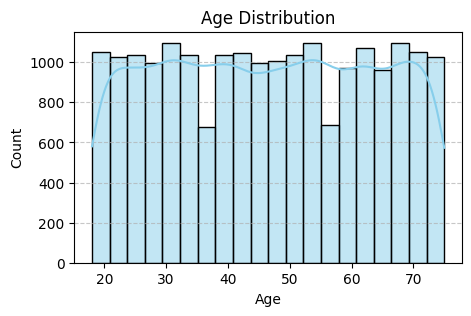

In [ ]:
# Checking age distribution to identify what is the target audience.
plt.figure(figsize=(5, 3))
sns.histplot(df_customers['age'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This shows that the age of our customers follows uniform distribution and not a normal distribution. No key insight here other than that the audience here is very diverse

In [ ]:
# Extract time-based features
df_final['order_year'] = df_final['order_time'].dt.year
df_final['order_month'] = df_final['order_time'].dt.month
df_final['order_day_of_week'] = df_final['order_time'].dt.dayofweek
df_final['order_hour'] = df_final['order_time'].dt.hour

/tmp/ipykernel_11241/949472606.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_year', data=df_final, palette='viridis')


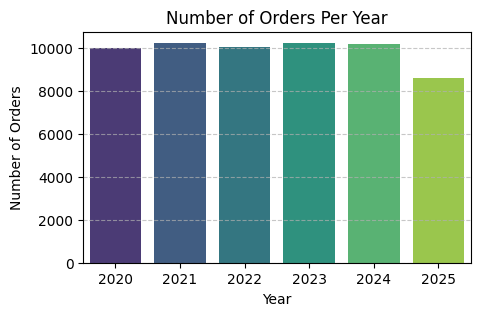

In [ ]:
# Plot orders by year
plt.figure(figsize=(5, 3))
sns.countplot(x='order_year', data=df_final, palette='viridis')
plt.title('Number of Orders Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_11241/282904640.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_month', data=df_final, palette='plasma')


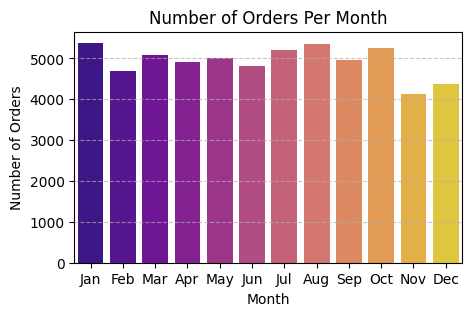

In [ ]:
# Plot orders by month
plt.figure(figsize=(5, 3))
sns.countplot(x='order_month', data=df_final, palette='plasma')
plt.title('Number of Orders Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(ticks=np.arange(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_11241/4181645579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_day_of_week', data=df_final, palette='mako')


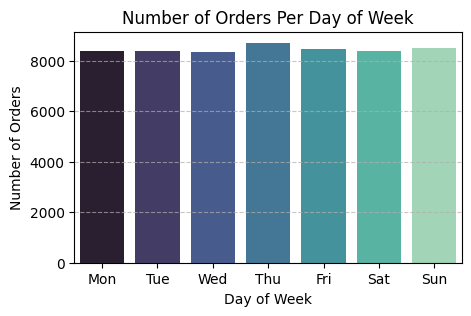

In [ ]:
# Plot orders by day of the week
plt.figure(figsize=(5, 3))
sns.countplot(x='order_day_of_week', data=df_final, palette='mako')
plt.title('Number of Orders Per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.xticks(ticks=np.arange(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_11241/1123213594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='order_hour', data=df_final, palette='rocket')


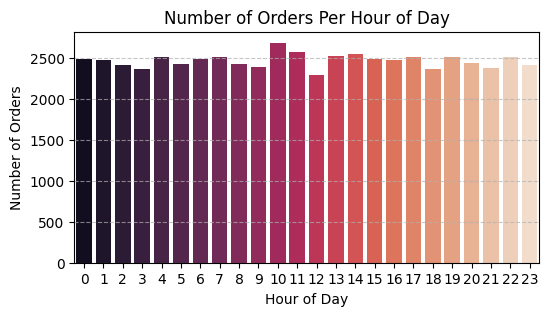

In [ ]:
# Plot orders by hour of the day
plt.figure(figsize=(6, 3))
sns.countplot(x='order_hour', data=df_final, palette='rocket')
plt.title('Number of Orders Per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Customer Demographics: Customers by Country

Let's visualize the distribution of customers across different countries to understand our customer base geographically.

/tmp/ipykernel_11241/3866549844.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='country', data=df_customers, order=df_customers['country'].value_counts().index, palette='viridis')


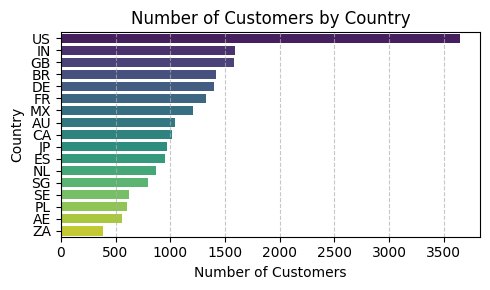

In [ ]:
plt.figure(figsize=(5, 3))
sns.countplot(y='country', data=df_customers, order=df_customers['country'].value_counts().index, palette='viridis')
plt.title('Number of Customers by Country')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Product Popularity by Country

To understand what products are popular in which country, we'll first identify the top countries by the number of orders. Then, we will look at the distribution of product categories within these top countries.

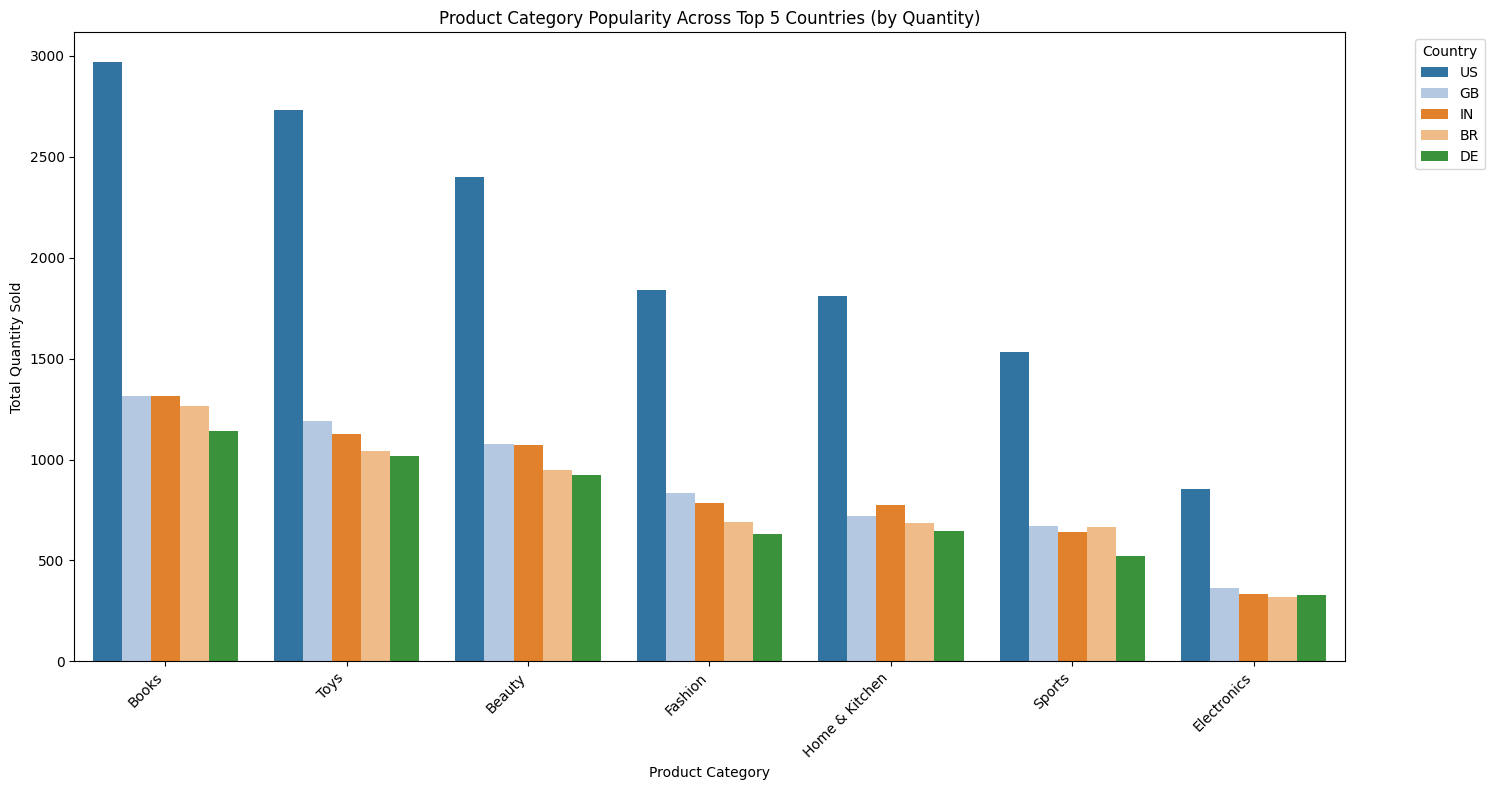

In [ ]:
# Identify top 5 countries by number of orders
top_countries = df_final['country_y'].value_counts().nlargest(5).index

# Filter the DataFrame for these top countries
df_top_countries = df_final[df_final['country_y'].isin(top_countries)]

# Aggregate product categories by country and sum quantities
category_by_country = df_top_countries.groupby(['country_y', 'category'])['quantity'].sum().reset_index()

# Calculate total quantity per category to get the order for sorting the x-axis categories
total_quantity_per_category = category_by_country.groupby('category')['quantity'].sum().sort_values(ascending=False).index

# Calculate the overall total quantity per country to define a global hue_order
country_overall_quantity_order = df_top_countries.groupby('country_y')['quantity'].sum().sort_values(ascending=False).index

plt.figure(figsize=(15, 8))
sns.barplot(x='category', y='quantity', hue='country_y', data=category_by_country, palette='tab20',
            order=total_quantity_per_category,
            hue_order=country_overall_quantity_order)
plt.title('Product Category Popularity Across Top 5 Countries (by Quantity)')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

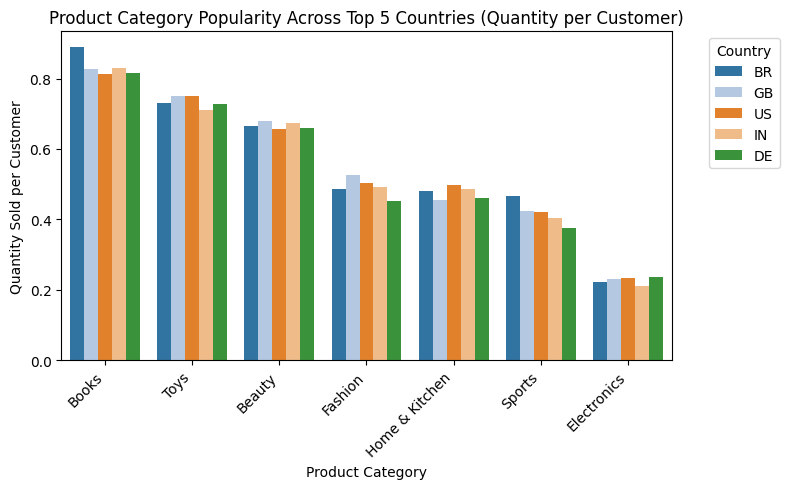

In [ ]:
# Identify top 5 countries by number of orders
top_countries = df_final['country_y'].value_counts().nlargest(5).index
# Filter the DataFrame for these top countries
df_top_countries = df_final[df_final['country_y'].isin(top_countries)]
# Aggregate product categories by country and sum quantities
category_by_country = df_top_countries.groupby(['country_y', 'category'])['quantity'].sum().reset_index()
# Calculate the number of unique customers per country
customers_per_country = df_customers[df_customers['country'].isin(top_countries)].groupby('country').size().reset_index(name='num_customers')
customers_per_country.rename(columns={'country': 'country_y'}, inplace=True)
# Merge to get quantity sold per customer
category_by_country = pd.merge(category_by_country, customers_per_country, on='country_y', how='left')
category_by_country['quantity_per_customer'] = category_by_country['quantity'] / category_by_country['num_customers']
# Calculate total quantity per category to get the order for sorting the x-axis categories
total_quantity_per_category = category_by_country.groupby('category')['quantity_per_customer'].sum().sort_values(ascending=False).index
# Calculate the overall average quantity per customer per country to define a global hue_order
country_overall_quantity_order = category_by_country.groupby('country_y')['quantity_per_customer'].sum().sort_values(ascending=False).index
plt.figure(figsize=(8, 5))
sns.barplot(x='category', y='quantity_per_customer', hue='country_y', data=category_by_country, palette='tab20',
            order=total_quantity_per_category,
            hue_order=country_overall_quantity_order)
plt.title('Product Category Popularity Across Top 5 Countries (Quantity per Customer)')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold per Customer')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

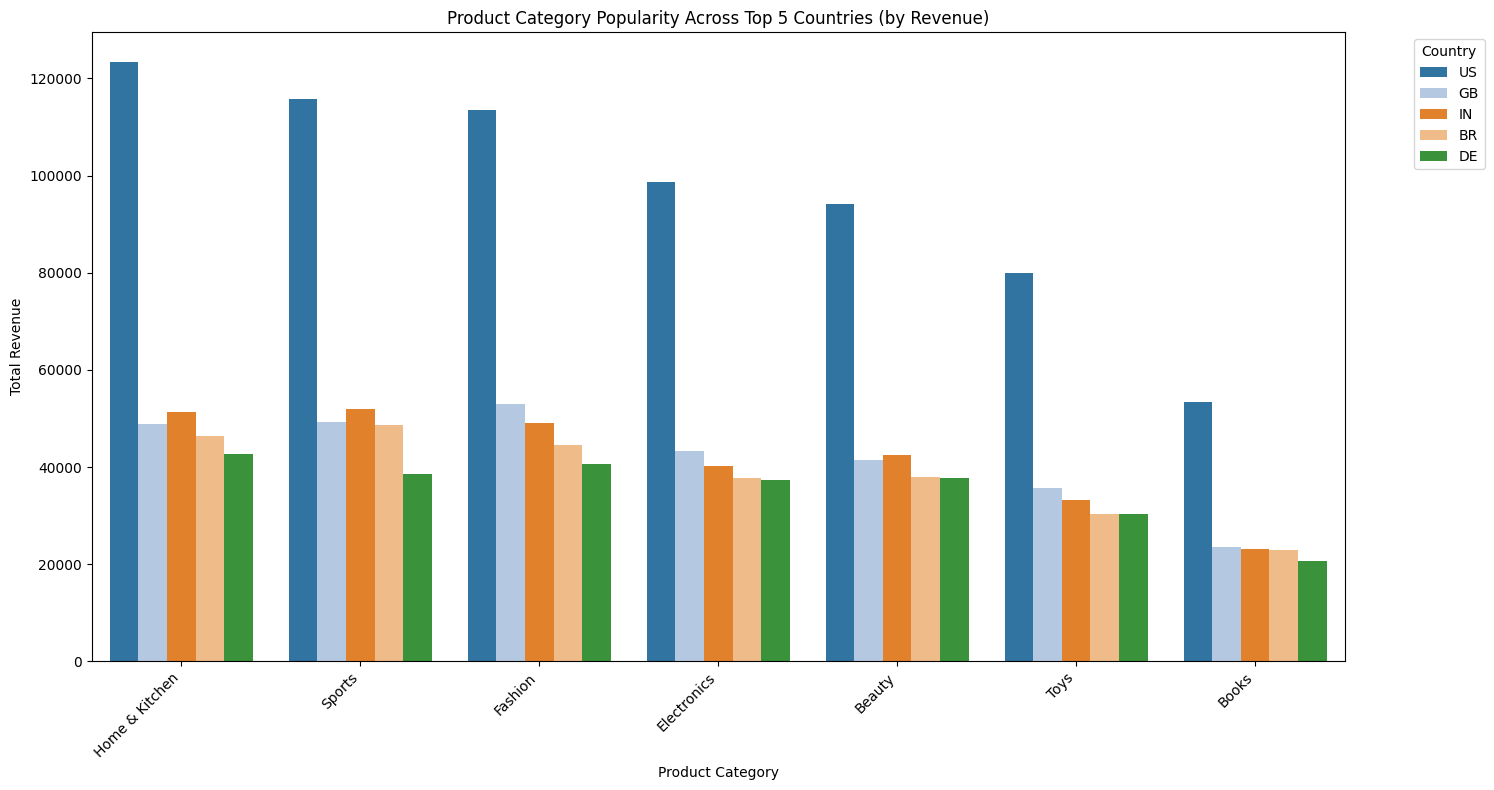

In [ ]:
# Identify top 5 countries by revenue
top_countries = df_final['country_y'].value_counts().nlargest(5).index

# Filter the DataFrame for these top countries
df_top_countries = df_final[df_final['country_y'].isin(top_countries)]

# Aggregate product categories by country and Revenue
category_by_country = df_top_countries.groupby(['country_y', 'category'])['price_usd'].sum().reset_index()

# Calculate total quantity per category to get the order for sorting the x-axis categories
total_revenue_per_category = category_by_country.groupby('category')['price_usd'].sum().sort_values(ascending=False).index

# Calculate the overall total REvenue per country to define a global hue_order
country_overall_revenue_order = df_top_countries.groupby('country_y')['price_usd'].sum().sort_values(ascending=False).index

plt.figure(figsize=(15, 8))
sns.barplot(x='category', y='price_usd', hue='country_y', data=category_by_country, palette='tab20',
            order=total_revenue_per_category,
            hue_order=country_overall_revenue_order)
plt.title('Product Category Popularity Across Top 5 Countries (by Revenue)')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
category_revenue = df_final.groupby('category')['price_usd'].sum().reset_index()
category_orders = df_final.groupby('category')['order_id'].nunique().reset_index(name='number_of_orders')
category_revenue = pd.merge(category_revenue, category_orders, on='category', how='left')
category_revenue = category_revenue.sort_values(by='price_usd', ascending=False)
display(category_revenue)

,category,price_usd,number_of_orders
4,Home & Kitchen,651481.39,5985
3,Fashion,639472.92,6267
5,Sports,632026.36,5284
2,Electronics,533762.00,3018
0,Beauty,531869.86,8055
6,Toys,433851.84,8878
1,Books,295194.27,9936


### Source Popularity by Country

Now, let's examine which event sources are most popular among these top countries.

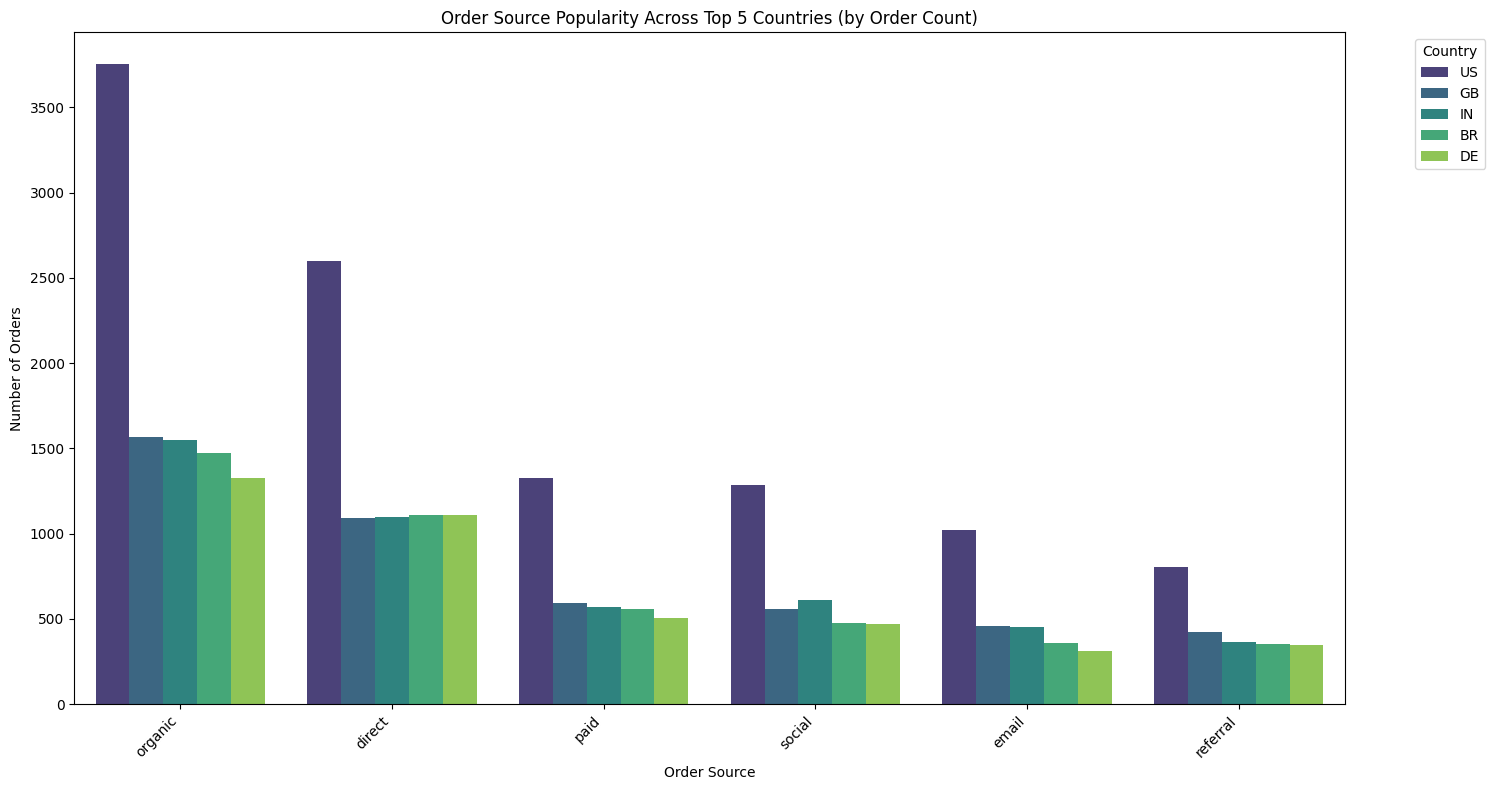

In [ ]:
# Aggregate order sources by country
source_by_country = df_top_countries.groupby(['country_y', 'source']).size().reset_index(name='order_count')

# Calculate overall total orders per source to order x-axis
total_orders_per_source = source_by_country.groupby('source')['order_count'].sum().sort_values(ascending=False).index

# Calculate overall total orders per country to order hue legend
total_orders_per_country = source_by_country.groupby('country_y')['order_count'].sum().sort_values(ascending=False).index

plt.figure(figsize=(15, 8))
sns.barplot(x='source', y='order_count', hue='country_y', data=source_by_country, palette='viridis',
            order=total_orders_per_source,
            hue_order=total_orders_per_country)
plt.title('Order Source Popularity Across Top 5 Countries (by Order Count)')
plt.xlabel('Order Source')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Channel Distribution Across Top 5 Countries

Let's visualize the distribution of order channels (sources) as a 100% stacked bar chart for the top 5 countries. This will show the relative importance of each channel within each country.

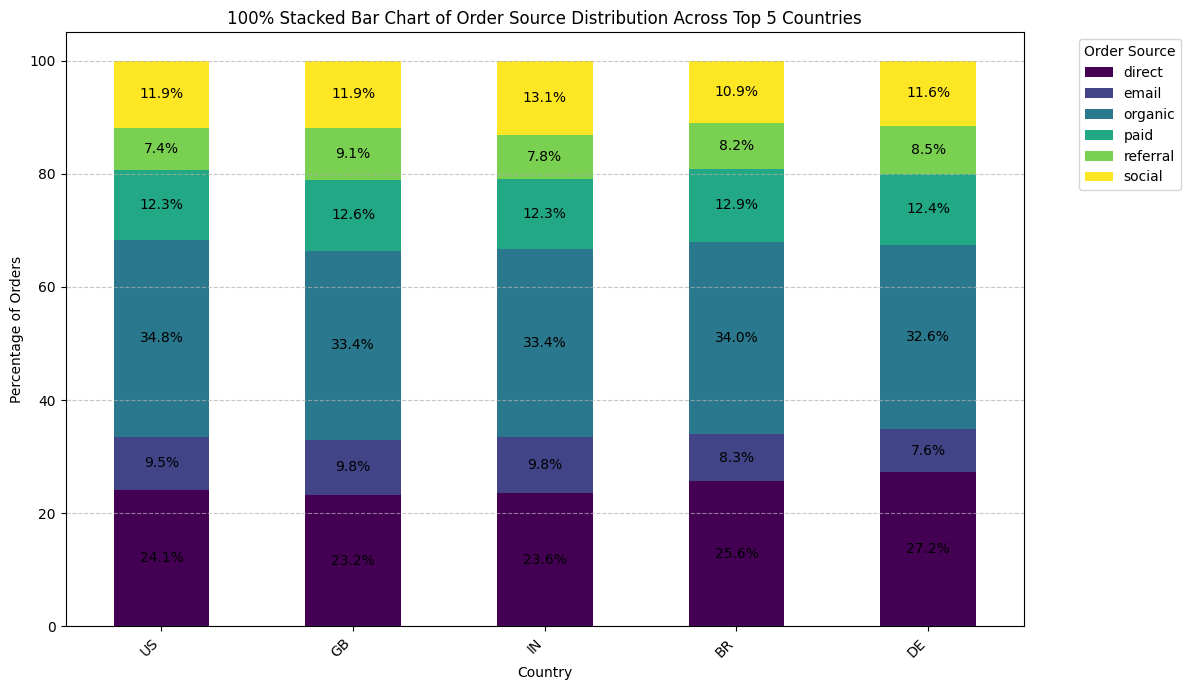

In [ ]:
# Calculate the total orders for each country in the top_countries list
total_orders_per_country_df = source_by_country.groupby('country_y')['order_count'].sum().reset_index(name='total_orders')

# Merge with source_by_country to calculate percentages
source_by_country_pct = pd.merge(source_by_country, total_orders_per_country_df, on='country_y', how='left')
source_by_country_pct['percentage'] = (source_by_country_pct['order_count'] / source_by_country_pct['total_orders']) * 100

# Pivot the table for plotting
pivoted_sources = source_by_country_pct.pivot(index='country_y', columns='source', values='percentage').fillna(0)

# Ensure countries are sorted by overall order count for consistency if desired
# (using total_orders_per_country_df from earlier)
pivoted_sources = pivoted_sources.loc[total_orders_per_country_df.sort_values(by='total_orders', ascending=False)['country_y']]

# Plotting the 100% stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
pivoted_sources.plot(kind='bar', stacked=True, colormap='viridis', ax=ax)
plt.title('100% Stacked Bar Chart of Order Source Distribution Across Top 5 Countries')
plt.xlabel('Country')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Order Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels to each stack
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fmt='%')

plt.tight_layout()
plt.show()

In [ ]:
df_final.columns

Index(['order_id', 'customer_id', 'order_time', 'payment_method',
       'discount_pct', 'subtotal_usd', 'total_usd', 'country_x', 'device',
       'source', 'name_x', 'email', 'country_y', 'age', 'signup_date',
       'marketing_opt_in', 'product_id', 'unit_price_usd', 'quantity',
       'line_total_usd', 'category', 'name_y', 'price_usd', 'cost_usd',
       'margin_usd', 'order_year', 'order_month', 'order_day_of_week',
       'order_hour'],
      dtype='object')

# First Observations
1. Top 3 countries in terms of Quantity sold is from US, GB and IN
2. Top 3 product category that were sold are Books, Toys and Beauty, However top 3 products by revenue are Home and Kitchen, Fashion, Sports. Suprisingly in this data set, electronics is not the most sold nor did it generate the most revenue - Something to ponder and deep dive.
3. Most Quantity per customer is from Brazil, GB, US and then IN.  
Shows that even with lesser number of customers, they bring in more orders than US which has more customers.
It might be easier to upsell/cross sell in Brazil and GB. GB is balanced with good number of customers as well as good no of orders per customer
4. Though business is popular in the US, the brand awareness is good in other countries as well. Mainly the South America, EU, and India. Can explore increasing awareness in Asia and the middle east
5.  Source wise, Social works better in IN, Referral is better in DE and BR, Overall Organic and Direct brings in the majority everywhere.



# Exploring the Events and Sessions for understanding the funnel

In [ ]:
  # Basic Data Profiling: Checking for missing elements
print("\nMissing values check in core columns:")
print(df_events[['session_id', 'event_type']].isnull().sum())



Missing values check in core columns:
session_id    0
event_type    0
dtype: int64


In [ ]:
traffic_breakdown = df_merged_events.groupby(['source', 'device'])['session_id'].nunique().reset_index()
traffic_breakdown.rename(columns={'session_id': 'unique_traffic_sessions'}, inplace=True)
print("\n--- Basic Traffic Profile Sample ---")
print(traffic_breakdown.head())


--- Basic Traffic Profile Sample ---
   source   device  unique_traffic_sessions
0  direct  desktop                    11289
1  direct   mobile                    16422
2  direct   tablet                     2150
3   email  desktop                     4119
4   email   mobile                     6044


In [ ]:
# ----------------------------------------------------
# 3. E-COMMERCE FUNNEL FLOW CALCULATIONS
# ----------------------------------------------------
print("\n--- Computing Funnel Flows ---")

# Aggregate user sessions mapping individual max-funnel thresholds
# Standard pipeline: page_view -> add_to_cart -> checkout -> purchase
funnel_counts = {
    "1_Page_Views": df_events[df_events['event_type'] == 'page_view']['session_id'].nunique(),
    "2_Cart_Additions": df_events[df_events['event_type'] == 'add_to_cart']['session_id'].nunique(),
    "3_Checkouts": df_events[df_events['event_type'] == 'checkout']['session_id'].nunique(),
    "4_Purchases": df_events[df_events['event_type'] == 'purchase']['session_id'].nunique()
}

df_funnel = pd.DataFrame(list(funnel_counts.items()), columns=['Funnel_Stage', 'Total_Sessions'])

# Add calculated progress metrics
base_traffic = df_funnel.loc[0, 'Total_Sessions']
df_funnel['Overall_Conversion_%'] = (df_funnel['Total_Sessions'] / base_traffic) * 100
df_funnel['Drop_Off_From_Prior_Stage_%'] = df_funnel['Total_Sessions'].pct_change() * 100
df_funnel['Drop_Off_From_Prior_Stage_%'] = df_funnel['Drop_Off_From_Prior_Stage_%'].apply(lambda x: 100 + x if x < 0 else 0)

print(df_funnel.to_string(index=False))


--- Computing Funnel Flows ---
    Funnel_Stage  Total_Sessions  Overall_Conversion_%  Drop_Off_From_Prior_Stage_%
    1_Page_Views          120000            100.000000                     0.000000
2_Cart_Additions           81518             67.931667                    67.931667
     3_Checkouts           44909             37.424167                    55.090900
     4_Purchases           33580             27.983333                    74.773431


In [ ]:
df_funnel

,Funnel_Stage,Total_Sessions,Overall_Conversion_%,Drop_Off_From_Prior_Stage_%
0,1_Page_Views,120000,100.000000,0.000000
1,2_Cart_Additions,81518,67.931667,67.931667
2,3_Checkouts,44909,37.424167,55.090900
3,4_Purchases,33580,27.983333,74.773431


# Creating RFM Segments for better understanding of our customer base

In [ ]:
# 4. CUSTOMER RFM COHORT SEGMENTATION

print("\n--- Executing RFM Mathematical Scoring ---")

# Define our static observation baseline (Day after the last transactional record in the data)
target_date = df_final['order_time'].max() + pd.Timedelta(days=1)

# Calculate absolute raw values
rfm = df_final.groupby('customer_id').agg({
    'order_time': lambda x: (target_date - x.max()).days, # Recency
    'order_id': 'nunique',                                # Frequency
    'line_total_usd': 'sum'                                 # Monetary (Check your dataset column name: total_price/total_amount)
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# Assign relative mathematical scores using 1-5 quantiles

# Low recency days = Excellent behavior -> give it a score of 5
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop')

# High frequency and high monetary spend = Excellent behavior -> give it a score of 5
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# Create an combined RFM rating matrix map
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Map numeric combinations into explicit business definitions
def tag_segments(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])

    if r == 5 and f == 5:
        return "Champions"
    elif r >= 4 and f == 1:
        return "New Customers"
    elif r >= 4 and f >= 4:
        return "Loyal"
    elif r >= 3 and f <= 2:
        return "Promising"
    elif r <= 2 and f >= 3:
        return "At Risk / Can't Lose Them"
    else:
        return "Hibernating / Churned"

rfm['Segment'] = rfm.apply(tag_segments, axis=1)

segment_summary = rfm.groupby('Segment').agg({
    'customer_id': 'count',
    'Monetary': 'mean',
    'Recency': 'mean'
}).rename(columns={'customer_id': 'Customer_Count', 'Monetary': 'Avg_Spend', 'Recency': 'Avg_Dormant_Days'}).reset_index()

print("\n--- Customer Segments Overview ---")
print(segment_summary.to_string(index=False))


--- Executing RFM Mathematical Scoring ---

--- Customer Segments Overview ---
                  Segment  Customer_Count  Avg_Spend  Avg_Dormant_Days
At Risk / Can't Lose Them            2632 345.705160       1241.786854
                Champions            1135 560.379471        105.023789
    Hibernating / Churned            7366 245.106806       1009.486288
                    Loyal            2497 426.451630        278.135362
            New Customers             745 146.244389        249.021477
                Promising            1893 163.984691        489.029583


In [ ]:
rfm

,customer_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,1,129,2,126.00,5,2,2,522,Promising
1,2,303,2,73.41,4,2,1,421,Promising
2,3,1946,1,78.50,1,1,1,111,Hibernating / Churned
3,4,823,2,306.75,3,2,4,324,Promising
4,5,275,3,278.49,4,4,4,444,Loyal
...,...,...,...,...,...,...,...,...,...
16263,19993,1221,3,738.87,2,5,5,255,At Risk / Can't Lose Them
16264,19994,1760,1,263.30,1,2,3,123,Hibernating / Churned
16265,19996,1309,1,77.10,2,2,1,221,Hibernating / Churned
16266,19998,372,4,578.64,4,5,5,455,Loyal


### Merging RFM Segments into the Final DataFrame

To analyze customer segments across different dimensions like countries and product categories, we first need to integrate the calculated RFM segments into our main `df_final` DataFrame.

In [ ]:
# Merge df_final with rfm to add the 'Segment' column
df_final_segmented = pd.merge(df_final, rfm[['customer_id', 'Segment']], on='customer_id', how='left')
display(df_final_segmented.head())

,order_id,customer_id,order_time,payment_method,discount_pct,subtotal_usd,total_usd,country_x,device,source,...,category,name_y,price_usd,cost_usd,margin_usd,order_year,order_month,order_day_of_week,order_hour,Segment
0,1,13917,2025-01-31 23:07:42,card,20,107.15,85.72,PL,desktop,organic,...,Home & Kitchen,Toaster MediumSlateBlue 575,107.15,65.65,41.50,2025,1,4,23,Promising
1,2,1022,2024-02-19 01:17:50,card,0,116.17,116.17,FR,tablet,organic,...,Fashion,Socks Orange 300,116.17,70.22,45.95,2024,2,0,1,Promising
2,3,6145,2024-12-04 20:24:13,card,0,137.35,137.35,US,mobile,organic,...,Beauty,Shampoo LawnGreen 601,94.49,58.26,36.23,2024,12,2,20,Hibernating / Churned
3,3,6145,2024-12-04 20:24:13,card,0,137.35,137.35,US,mobile,organic,...,Electronics,SSD Orchid 272,42.86,27.37,15.49,2024,12,2,20,Hibernating / Churned
4,4,3152,2024-07-17 08:50:47,card,15,32.18,27.35,BR,mobile,email,...,Toys,Board Game DarkSeaGreen 297,32.18,22.43,9.75,2024,7,2,8,Hibernating / Churned


In [ ]:
rfm_segment_colors = {
    "Champions": "#4CAF50",  # Green
    "Loyal": "#8BC34A",      # Light Green
    "Promising": "#FFC107",  # Amber
    "New Customers": "#2196F3", # Blue
    "At Risk / Can't Lose Them": "#FF9800", # Orange
    "Hibernating / Churned": "#F44336" # Red
}


### RFM Segment Distribution by Country

Now, let's visualize how the different customer segments are distributed across countries. This can highlight if certain countries have a higher concentration of 'Champions', 'Loyal', or 'At Risk' customers.

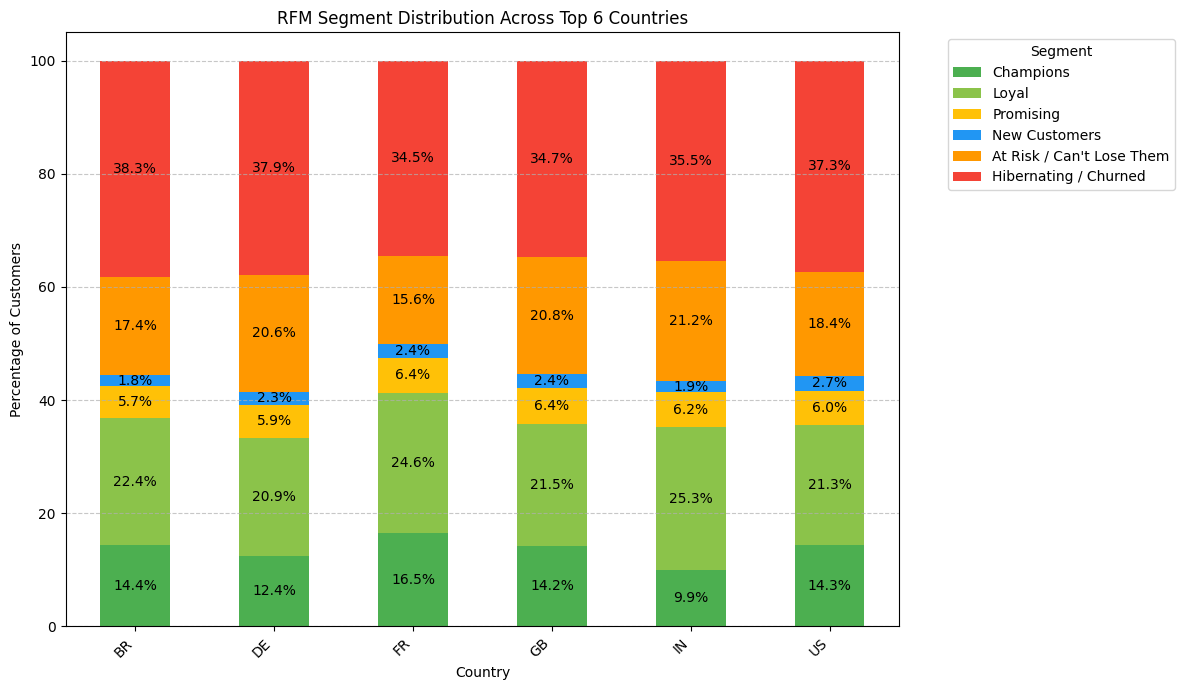

In [ ]:
# Calculate segment counts per country
segment_country_counts = df_final_segmented.groupby(['country_y', 'Segment']).size().unstack(fill_value=0)

# Convert to percentages
segment_country_percentages = segment_country_counts.div(segment_country_counts.sum(axis=1), axis=0) * 100

# Sort countries by total number of orders for consistency (optional, but good practice)
top_countries = df_final_segmented['country_y'].value_counts().nlargest(6).index
segment_country_percentages = segment_country_percentages.loc[segment_country_percentages.index.intersection(top_countries)]

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
# Ensure the columns for plotting match the keys in rfm_segment_colors
ordered_segments = [seg for seg in rfm_segment_colors if seg in segment_country_percentages.columns]
segment_country_percentages[ordered_segments].plot(kind='bar', stacked=True, color=[rfm_segment_colors[seg] for seg in ordered_segments], ax=ax)

plt.title('RFM Segment Distribution Across Top 6 Countries')
plt.xlabel('Country')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels to each stack
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fmt='%')

plt.tight_layout()
plt.show()

### RFM Segment Distribution by Product Category

Next, let's analyze how customer segments are distributed across different product categories. This can reveal if certain product categories attract specific types of customers (e.g., 'Champions' buying 'Electronics' or 'New Customers' buying 'Books').

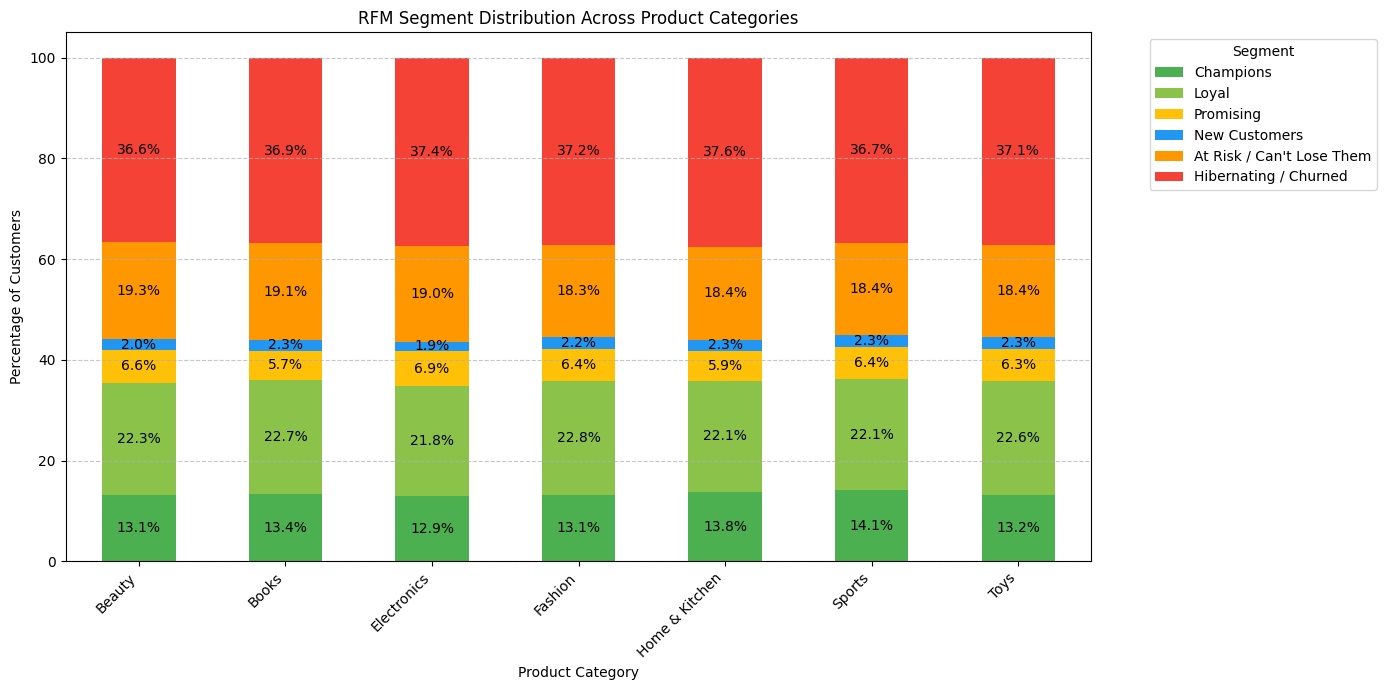

In [ ]:
# Calculate segment counts per product category
segment_category_counts = df_final_segmented.groupby(['category', 'Segment']).size().unstack(fill_value=0)

# Convert to percentages
segment_category_percentages = segment_category_counts.div(segment_category_counts.sum(axis=1), axis=0) * 100

# Sort categories by total revenue or quantity for consistency (optional)
total_category_revenue = df_final_segmented.groupby('category')['price_usd'].sum().sort_values(ascending=False).index
segment_category_percentages = segment_category_percentages.loc[segment_category_percentages.index.intersection(total_category_revenue)]

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
# Ensure the columns for plotting match the keys in rfm_segment_colors
ordered_segments = [seg for seg in rfm_segment_colors if seg in segment_category_percentages.columns]
segment_category_percentages[ordered_segments].plot(kind='bar', stacked=True, color=[rfm_segment_colors[seg] for seg in ordered_segments], ax=ax)

plt.title('RFM Segment Distribution Across Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels to each stack
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fmt='%')

plt.tight_layout()
plt.show()

### RFM Segment Counts per Country

To provide another view of the RFM segment distribution, here's a bar chart showing the absolute counts of each segment for each country.

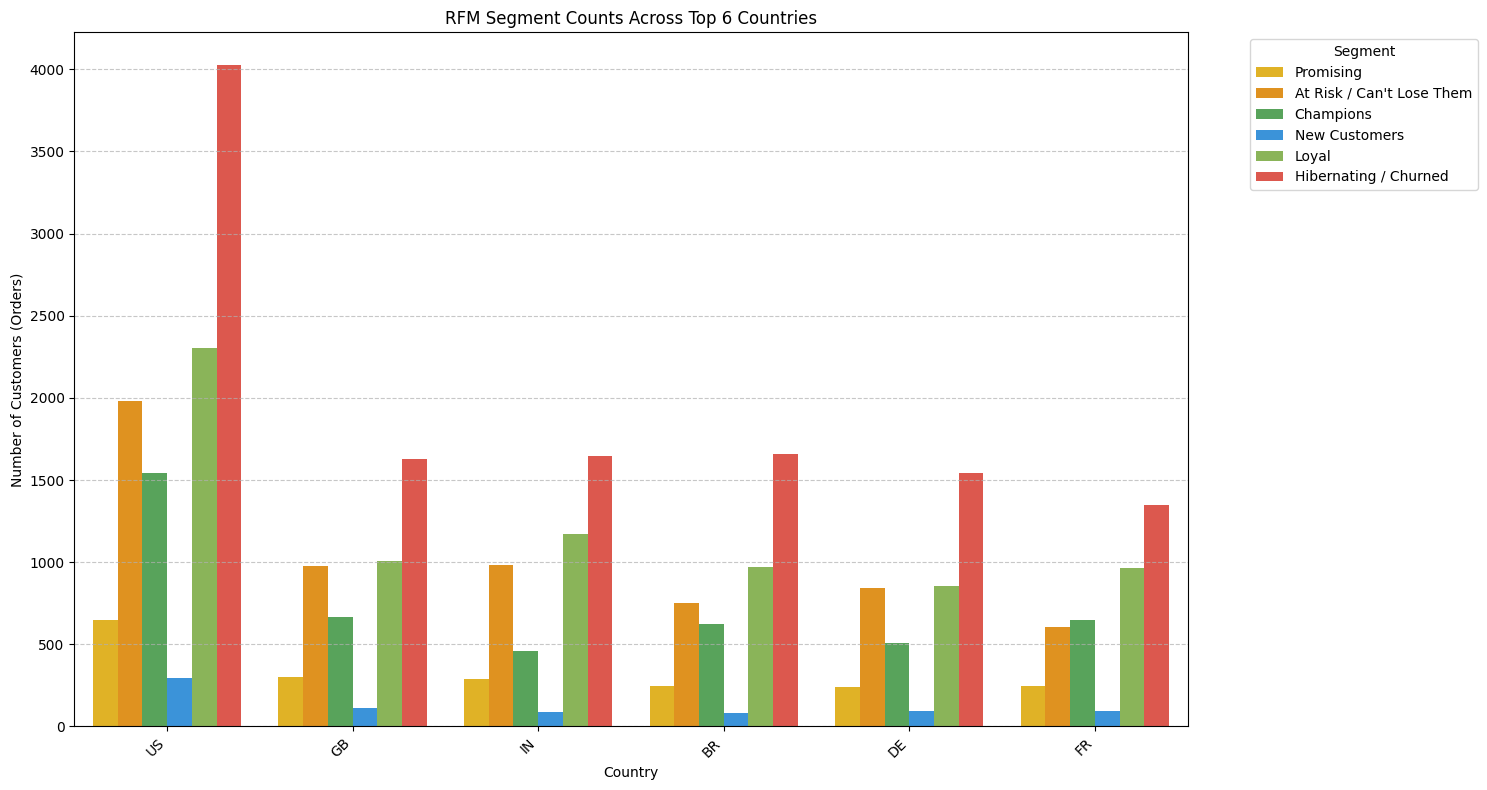

In [ ]:
# Calculate segment counts per country
segment_country_counts = df_final_segmented.groupby(['country_y', 'Segment']).size().reset_index(name='Count')

# Sort countries by total number of customers for consistency
top_countries_order = df_final_segmented['country_y'].value_counts().nlargest(6).index
segment_country_counts = segment_country_counts[segment_country_counts['country_y'].isin(top_countries_order)]
segment_country_counts['country_y'] = pd.Categorical(segment_country_counts['country_y'], categories=top_countries_order, ordered=True)
segment_country_counts = segment_country_counts.sort_values('country_y')

plt.figure(figsize=(15, 8))
sns.barplot(x='country_y', y='Count', hue='Segment', data=segment_country_counts, palette=rfm_segment_colors)
plt.title('RFM Segment Counts Across Top 6 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Customers (Orders)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### RFM Segment Counts per Product Category

Similarly, here's a bar chart illustrating the absolute counts of each RFM segment within each product category.

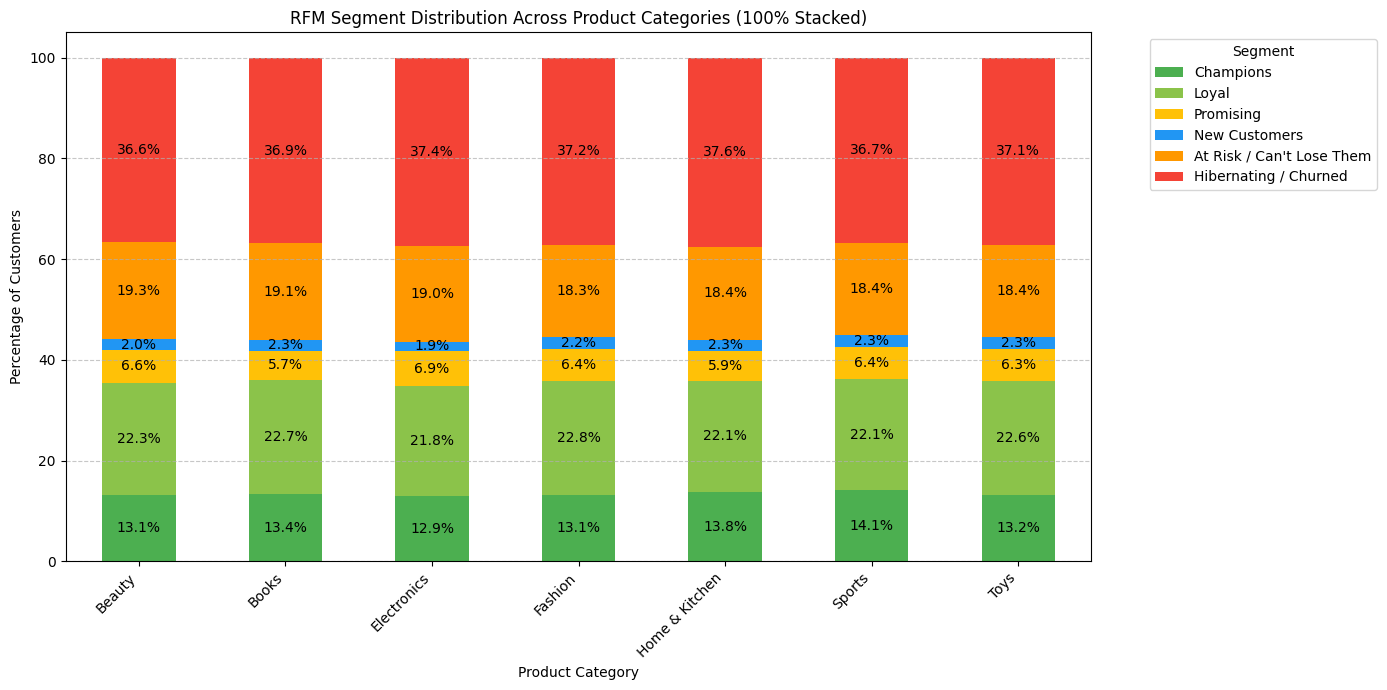

In [ ]:
# Calculate segment counts per product category
segment_category_counts = df_final_segmented.groupby(['category', 'Segment']).size().unstack(fill_value=0)

# Convert to percentages
segment_category_percentages = segment_category_counts.div(segment_category_counts.sum(axis=1), axis=0) * 100

# Sort categories by total revenue for consistency (optional)
total_category_revenue = df_final_segmented.groupby('category')['price_usd'].sum().sort_values(ascending=False).index
segment_category_percentages = segment_category_percentages.loc[segment_category_percentages.index.intersection(total_category_revenue)]

# Plotting
fig, ax = plt.subplots(figsize=(14, 7))
# Ensure the columns for plotting match the keys in rfm_segment_colors
ordered_segments = [seg for seg in rfm_segment_colors if seg in segment_category_percentages.columns]
segment_category_percentages[ordered_segments].plot(kind='bar', stacked=True, color=[rfm_segment_colors[seg] for seg in ordered_segments], ax=ax)

plt.title('RFM Segment Distribution Across Product Categories (100% Stacked)')
plt.xlabel('Product Category')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentage labels to each stack
for container in ax.containers:
    labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fmt='%')

plt.tight_layout()
plt.show()

# Insights and Recommendations so far

## Customer Demographics

**Insight:** The United States, India, Great Britain and = Brazil consistently rank as the top countries by customer count and order volume.

**Recommendation**: These are core markets for concentrated growth efforts. Investing in country-specific localization (e.g., local payment methods, language, region-specific promotions) could significantly enhance customer experience and sales in these regions.

In the Asia and the Middle-East - Develop Brand Awareness Campaigns - Do a field research on competitors to build better strategy to venture into the market

**Other Observations:** The age group is diverse and uniformly distributed, product categories in the shop are also pretty diverse at the current state.

## Channel Overview

**Insight:** 'Organic' and 'Direct' traffic are the primary drivers of orders across all top countries.

**Recommendation:** Continuously optimizing SEO, brand content, and user experience for direct visitors should be a priority.

**Insight:** 'Social' media performs notably better in India, while 'Referral' programs are more effective in Denmark and Brazil.

**Recommendation:** Tailor marketing channel strategies to country-specific strengths could yield better ROI.

**Further Actions:** Drive experiments (A/B tests, MultiVariate Tests) to understand this hypothesis and refine preferences.


## RFM Insights

**Insight:** Large 'Hibernating / Churned' Segment: A substantial portion of the customer base (around **35-38%**) across all countries and product categories falls into the 'Hibernating / Churned' segment.

**Recommendation:** This represents a significant opportunity for win-back campaigns. Targeted re-engagement strategies with compelling offers could reactivate a large number of customers. Conversely, it could indicate issues with long-term retention strategies.

**Insight:** The 'New Customers' segment is consistently small (2-3%)

**Recommendation:** Focus on improving the onboarding experience for new customers to transition them quickly into 'Promising' or 'Loyal' segments.

**Insight:** 'Champions' make up about **(10-16%)** proving them as a valuable, albeit smaller, loyal group.

**Recommendation:** Prioritize retention and exclusive offers to maximize their lifetime value.

**Insight:** Category-Specific RFM Trends: 'Beauty' and 'Books' show slightly higher 'New Customers' percentages, while 'Home & Kitchen' and 'Sports' have slightly more 'Champions'.

**Recommendation:**  'Beauty' and 'Books' could be excellent entry-point categories for new customer acquisition. For 'Home & Kitchen' and 'Sports', strategies to nurture loyalty and encourage repeat purchases from existing 'Champions' could be most effective.

**Further Actions:** Conduct experiments - between differnt groups with Geo Lifts and Hold Out tests to strengthen these hypotheses and build successful campaigns
